REPLICATION OF FIGURES

COMMON SETUP FOR FIGURE REPLICATION

In [63]:
# IMPORTING THE REQUIRED LIBRARIES 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyBigWig
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


In [64]:
# EDITING THE PATHS

# PATH FOR THE PEAKS
PEAKS_WT = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/peaks/cDC1_WT_2_peaks.narrowPeak"
PEAKS_KO = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/peaks/cDC1_KO_2_peaks.narrowPeak"

# PATH FOR THE BIGWIG FILES 
BW_WT_H3K27AC = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/WT_H3K27ac.bw"
BW_KO_H3K27AC = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/KO_H3K27ac.bw"

# PARAMETERS FOR PEAK CENTER FOR HEATMAPS 
FLANK_BP = 2000  
BIN_BP   = 50    

# PATH FOR RNA RAW COUNTS
RNA_COUNTS_CDC1 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/GSE266583_cDC1_Raw_counts.tsv"
RNA_COUNTS_CDC2 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/GSE266583_cDC2_Raw_counts.tsv"

# CSV SAMPLESHEETS
SAMPLES_CDC1 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/cdc1_rna_samples.csv"
SAMPLES_CDC2 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/cdc2_rna_samples.csv"

# ATAC DAR TABLES
ATAC_DAR_CDC1 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/cdc1_atac_DAR_with_genes.tsv"
ATAC_DAR_CDC2 = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/cdc2_atac_DAR_with_genes.tsv"

FDR = 0.05

REPLICATION OF FIGURE 6A AND 6B

In [65]:
# READING THE NARROWPEAK AND DEFINING PEAK CENTERS 

def read_narrowpeak(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, comment="#")
    df = df.iloc[:, :10].copy()
    df.columns = ["chr","start","end","name","score","strand","signalValue","pValue","qValue","peak"]
    summit = df["start"] + df["peak"].where(df["peak"] >= 0, ((df["end"] - df["start"]) // 2))
    df["center"] = summit.astype(int)
    return df[["chr","start","end","center","signalValue","qValue"]]

peaks_wt = read_narrowpeak(PEAKS_WT)
peaks_ko = read_narrowpeak(PEAKS_KO)

print("WT peaks:", len(peaks_wt))
print("KO peaks:", len(peaks_ko))
peaks_wt.head()

WT peaks: 84466
KO peaks: 103639


,chr,start,end,center,signalValue,qValue
0,GL456210.1,543,1057,892,6.76101,21.06090
1,GL456210.1,4235,4673,4514,7.95964,38.59060
2,GL456210.1,8249,8643,8434,5.14512,14.67950
3,GL456210.1,32214,32494,32316,3.76884,4.08553
4,GL456210.1,75443,75949,75799,6.80556,23.90120


In [66]:
# BUILDING SIGNAL MATRIX FROM BIGWIG AROUND PEAK CENTERS 

def bw_values_vector(bw: pyBigWig.pyBigWig, chrom: str, start: int, end: int) -> np.ndarray:
    vals = bw.values(chrom, start, end, numpy=True)
    vals = np.array(vals, dtype=float)
    return vals

def binned_mean(vec: np.ndarray, bin_bp: int) -> np.ndarray:
    L = len(vec)
    if L % bin_bp != 0:
        vec = vec[: L - (L % bin_bp)]
    return np.nanmean(vec.reshape(-1, bin_bp), axis=1)

def make_signal_matrix(peaks_df: pd.DataFrame,
                       bw_signal_path: str,
                       flank_bp: int = 2000,
                       bin_bp: int = 50,
                       bw_control_path: str | None = None,
                       max_peaks: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    
    peaks_use = peaks_df.copy()
    if max_peaks is not None and len(peaks_use) > max_peaks:
        peaks_use = peaks_use.sample(max_peaks, random_state=0).reset_index(drop=True)

    bw_sig = pyBigWig.open(bw_signal_path)
    bw_ctl = pyBigWig.open(bw_control_path) if bw_control_path else None

    win = 2 * flank_bp
    n_bins = win // bin_bp
    M = np.full((len(peaks_use), n_bins), np.nan, dtype=float)

    for i, (chrom, center) in enumerate(zip(peaks_use["chr"], peaks_use["center"])):
        start = int(center - flank_bp)
        end   = int(center + flank_bp)

        if start < 0:
            continue

        try:
            sig = bw_values_vector(bw_sig, chrom, start, end)
            if bw_ctl is not None:
                ctl = bw_values_vector(bw_ctl, chrom, start, end)
                sig = sig - ctl

            M[i, :] = binned_mean(sig, bin_bp=bin_bp)
        except RuntimeError:
            continue

    bw_sig.close()
    if bw_ctl is not None:
        bw_ctl.close()

    x = np.linspace(-flank_bp, flank_bp, n_bins, endpoint=False) + (bin_bp / 2)
    return M, x

M_wt, x = make_signal_matrix(peaks_wt, BW_WT_H3K27AC, flank_bp=FLANK_BP, bin_bp=BIN_BP)
M_ko, _ = make_signal_matrix(peaks_ko, BW_KO_H3K27AC, flank_bp=FLANK_BP, bin_bp=BIN_BP)

print("WT matrix:", M_wt.shape, "KO matrix:", M_ko.shape)

WT matrix: (84466, 80) KO matrix: (103639, 80)


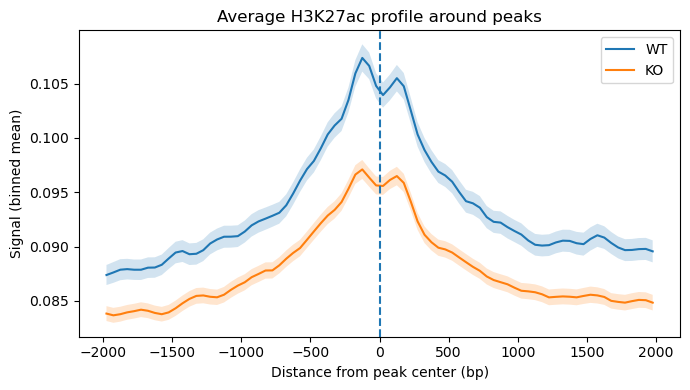

In [67]:
# BUILDING THE AVERAGE PROFILE PLOT

def plot_average_profile(M: np.ndarray, x: np.ndarray, label: str):
    mean = np.nanmean(M, axis=0)
    sem  = np.nanstd(M, axis=0) / np.sqrt(np.sum(~np.isnan(M), axis=0).clip(min=1))

    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - sem, mean + sem, alpha=0.2)

plt.figure(figsize=(7,4))
plot_average_profile(M_wt, x, "WT")
plot_average_profile(M_ko, x, "KO")
plt.axvline(0, linestyle="--")
plt.xlabel("Distance from peak center (bp)")
plt.ylabel("Signal (binned mean)")
plt.title("Average H3K27ac profile around peaks")
plt.legend()
plt.tight_layout()
plt.show()

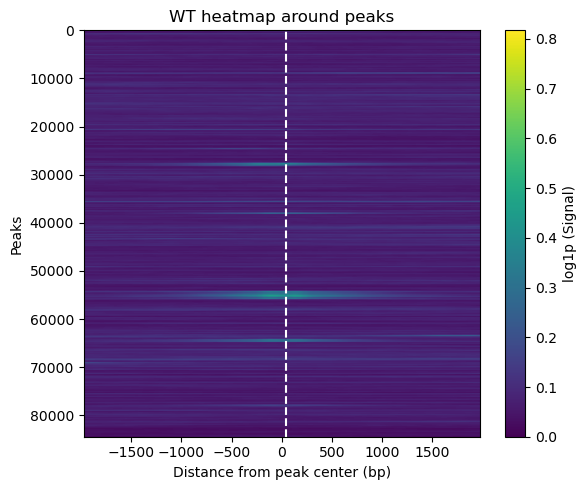

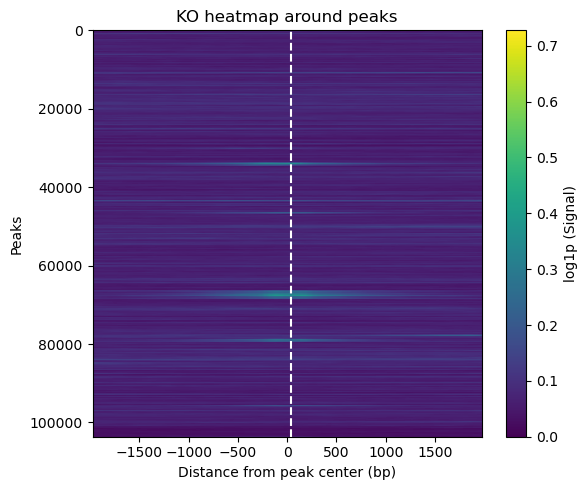

In [68]:
# BUILDING THE HEATMAPS 

def plot_heatmap(M, x, title):
    M = np.nan_to_num(M, nan=0.0)
    Mlog = np.log1p(M)

    vmax = np.percentile(Mlog, 99)
    plt.figure(figsize=(6,5))
    plt.imshow(
        Mlog,
        aspect="auto",
        origin="upper",
        extent=[x[0], x[-1], Mlog.shape[0], 0],
        vmin=0,
        vmax=vmax,
    )
    plt.axvline(Mlog.shape[1]//2, ls="--", c="white")
    plt.colorbar(label="log1p (Signal)")
    plt.xlabel("Distance from peak center (bp)")
    plt.ylabel("Peaks")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(M_wt, x, "WT heatmap around peaks")
plot_heatmap(M_ko, x, "KO heatmap around peaks")


REPLICATION OF FIGURE 6C AND 6E

In [85]:
# SETTING UP FOR REPLICATION OF FIGURE 6C AND 6E

def load_counts_tsv(path):
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={df.columns[0]: "gene"}).set_index("gene")

    # numeric + int counts
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # DESeq2 expects integers (counts)
    df = df.round(0).astype(int)
    return df

def load_sample_sheet(path):
    meta = pd.read_csv(path)
    if not {"sample", "condition"}.issubset(meta.columns):
        raise ValueError("Sample sheet must contain columns: sample, condition")

    meta = meta.copy()
    meta["sample"] = meta["sample"].astype(str)
    meta["condition"] = meta["condition"].astype(str)

    # safety: only keep rows with known conditions
    meta = meta[meta["condition"].isin(["WT", "KO"])].copy()

    # safety: drop duplicate sample rows if any
    meta = meta.drop_duplicates(subset=["sample"], keep="first")

    return meta

def run_pydeseq2(counts_df, meta_df, ref_condition="WT"):
    # ensure meta samples exist in counts
    missing = set(meta_df["sample"]) - set(counts_df.columns)
    if missing:
        raise ValueError(f"Samples in meta not found in counts columns: {sorted(missing)}")

    # pydeseq2 expects samples x genes
    counts = counts_df[meta_df["sample"]].T
    meta   = meta_df.set_index("sample").loc[counts.index].copy()

    dds = DeseqDataSet(
        counts=counts,
        metadata=meta,                 
        design_factors="condition",
        refit_cooks=True,
        n_cpus=1,
    )
    dds.deseq2()

    stat = DeseqStats(dds, contrast=("condition", "KO", ref_condition))
    stat.summary()

    res = stat.results_df.copy()
    res.index.name = "gene"
    res = res.reset_index().rename(
        columns={"log2FoldChange": "rna_log2fc", "padj": "rna_fdr"}
    )

    # keep only what we need
    return res[["gene", "rna_log2fc", "rna_fdr"]]

def load_atac_gene_table(path):
    df = pd.read_csv(path, sep="\t")

    required = {"gene", "atac_log2fc", "atac_fdr"}
    if not required.issubset(df.columns):
        raise ValueError(f"ATAC file must contain {required}, found: {df.columns.tolist()}")

    df = df.dropna(subset=["gene", "atac_log2fc", "atac_fdr"]).copy()

    # if multiple rows per gene, keep strongest abs(log2FC)
    df["abs_lfc"] = df["atac_log2fc"].abs()
    df = df.sort_values("abs_lfc", ascending=False).drop_duplicates("gene")

    return df[["gene", "atac_log2fc", "atac_fdr"]]

In [ ]:
GTF_GZ = "/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/refs/gencode.vM38.primary_assembly.annotation.gtf.gz"

def build_ensembl_to_symbol_map(gtf_gz_path):
    mapping = {}
    with gzip.open(gtf_gz_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            feature = parts[2]
            if feature != "gene":
                continue
            attrs = parts[8]

            gene_id = None
            gene_name = None

            for field in attrs.split(";"):
                field = field.strip()
                if field.startswith("gene_id"):
                    gene_id = field.split(" ")[1].replace('"', "")
                elif field.startswith("gene_name"):
                    gene_name = field.split(" ")[1].replace('"', "")

            if gene_id and gene_name:
                gene_id = gene_id.split(".")[0]   # strip version
                mapping[gene_id] = gene_name

    return mapping

ens2sym = build_ensembl_to_symbol_map(GTF_GZ)
print("Mapping size:", len(ens2sym))

Mapping size: 78334


In [88]:
def load_atac_gene_table_symbol(path, ens2sym):
    df = pd.read_csv(path, sep="\t")

    required = {"gene","atac_log2fc","atac_fdr"}
    if not required.issubset(df.columns):
        raise ValueError(f"ATAC file must contain {required}, found: {df.columns.tolist()}")

    df = df.dropna(subset=["gene","atac_log2fc","atac_fdr"]).copy()

    # gene is Ensembl -> strip version -> map to symbol
    df["gene"] = df["gene"].astype(str).str.replace(r"\.\d+$", "", regex=True)
    df["gene"] = df["gene"].map(ens2sym)   

    # drop genes we couldn't map
    df = df.dropna(subset=["gene"]).copy()

    # collapse multiple peaks per gene: keep strongest abs(log2FC)
    df["abs_lfc"] = df["atac_log2fc"].abs()
    df = df.sort_values("abs_lfc", ascending=False).drop_duplicates("gene")

    # return clean table (only one 'gene' column!)
    return df[["gene","atac_log2fc","atac_fdr"]]


/scratch/2294385.1.academic/ipykernel_526537/1877121514.py:40: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 12.10 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 12.63 seconds.

Fitting LFCs...
... done in 6.81 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.15 seconds.



Log2 fold change & Wald test p-value: condition KO vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                       
Gnai3          3687.230935        0.060713  0.130058  0.466813  0.640634   
Cdc45          3598.053310       -0.072728  0.274406 -0.265038  0.790980   
Scml2             6.032108       -0.914645  1.172376 -0.780163  0.435295   
Narf            727.136267       -0.147551  0.193479 -0.762616  0.445692   
Cav2             42.532367        0.982284  0.517291  1.898902  0.057577   
...                    ...             ...       ...       ...       ...   
A930007A09Rik    42.758923        0.019775  0.448710  0.044071  0.964848   
Gm7592          573.140667        0.753427  0.180691  4.169699  0.000031   
Ccl19-ps2       320.555161        0.043128  0.364794  0.118225  0.905889   
Gm21104         320.555161        0.043128  0.364794  0.118225  0.905889   
Gm2296            6.255086     

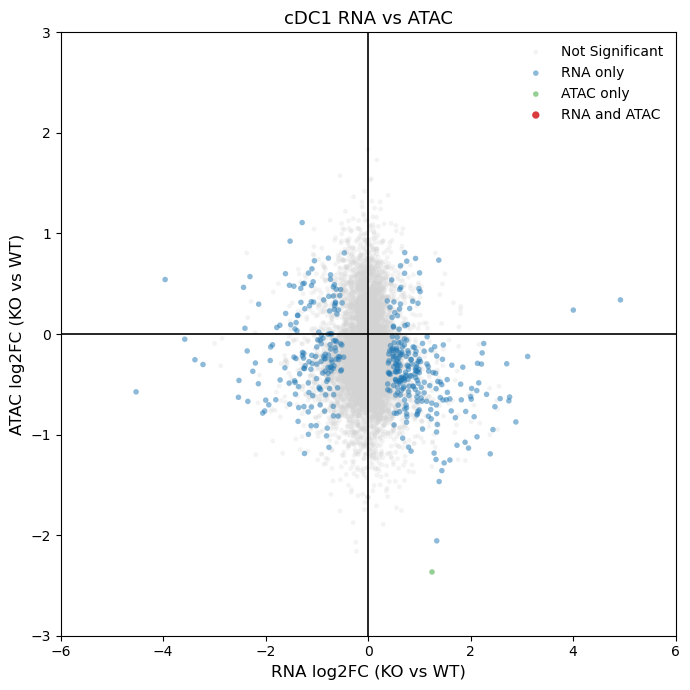

/scratch/2294385.1.academic/ipykernel_526537/1877121514.py:40: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 11.22 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 11.94 seconds.

Fitting LFCs...
... done in 6.11 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.98 seconds.



Log2 fold change & Wald test p-value: condition KO vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene                                                                       
Gnai3          3064.328176        0.062702  0.097114  0.645657  0.518501   
Cdc45          1543.895196       -0.273279  0.133338 -2.049518  0.040411   
Scml2            10.198295        0.284488  0.821133  0.346457  0.728999   
Narf            897.443590       -0.017078  0.132883 -0.128517  0.897740   
Cav2             85.915635        0.796153  0.260350  3.058012  0.002228   
...                    ...             ...       ...       ...       ...   
A930007A09Rik    44.921854        0.310318  0.340298  0.911900  0.361822   
Gm7592          353.266365       -0.248804  0.172692 -1.440737  0.149659   
Ccl19-ps2        67.535585        0.541547  0.348381  1.554470  0.120072   
Gm21104          67.535585        0.541547  0.348381  1.554470  0.120072   
Gm2296            1.628385     

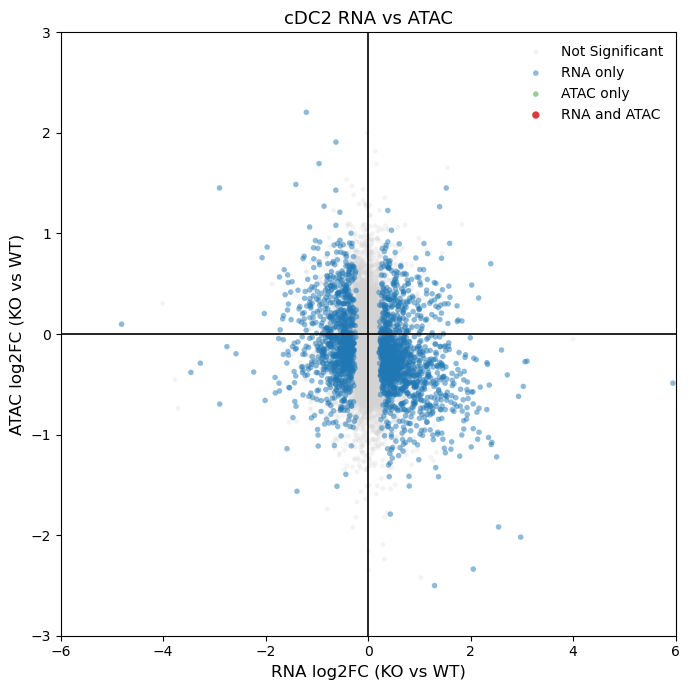

In [102]:
def plot_rna_vs_atac_(rna_res, atac_res, title, fdr=0.05, xlim=None, ylim=None):
    merged = pd.merge(rna_res, atac_res, on="gene", how="inner").dropna()
    print(title, "| merged genes:", merged.shape[0])

    if merged.shape[0] == 0:
        raise ValueError(
            "Merge produced 0 rows. ID mismatch.\n"
            f"RNA example genes: {rna_res['gene'].head(5).tolist()}\n"
            f"ATAC example genes: {atac_res['gene'].head(5).tolist()}"
        )

    merged["sig_rna"]  = merged["rna_fdr"]  < fdr
    merged["sig_atac"] = merged["atac_fdr"] < fdr
    merged["sig_both"] = merged["sig_rna"] & merged["sig_atac"]

    # base plot
    plt.figure(figsize=(7, 7))

    # not significant
    ns = merged[~merged["sig_rna"] & ~merged["sig_atac"]]
    plt.scatter(
        ns["rna_log2fc"], ns["atac_log2fc"],
        s=12, alpha=0.25, color="lightgray",
        edgecolors="none", label="Not Significant"
    )

    # RNA only
    rna_only = merged[merged["sig_rna"] & ~merged["sig_atac"]]
    plt.scatter(
        rna_only["rna_log2fc"], rna_only["atac_log2fc"],
        s=16, alpha=0.5, color="#1f77b4",
        edgecolors="none", label="RNA only"
    )

    # ATAC only
    atac_only = merged[~merged["sig_rna"] & merged["sig_atac"]]
    plt.scatter(
        atac_only["rna_log2fc"], atac_only["atac_log2fc"],
        s=16, alpha=0.5, color="#2ca02c",
        edgecolors="none", label="ATAC only"
    )

    # both significant
    both = merged[merged["sig_both"]]
    plt.scatter(
        both["rna_log2fc"], both["atac_log2fc"],
        s=28, alpha=0.9, color="#d62728",
        edgecolors="none", label="RNA and ATAC"
    )

    # zero lines
    plt.axvline(0, color="black", linewidth=1.2)
    plt.axhline(0, color="black", linewidth=1.2)

    plt.xlabel("RNA log2FC (KO vs WT)", fontsize=12)
    plt.ylabel("ATAC log2FC (KO vs WT)", fontsize=12)
    plt.title(title, fontsize=13)

    if xlim is not None: plt.xlim(*xlim)
    if ylim is not None: plt.ylim(*ylim)

    plt.legend(frameon=False)
    plt.tight_layout()

    return merged


# cDC1
rna1  = run_pydeseq2(load_counts_tsv(RNA_COUNTS_CDC1), load_sample_sheet(SAMPLES_CDC1))
atac1 = load_atac_gene_table_symbol(ATAC_DAR_CDC1, ens2sym)

m1 = plot_rna_vs_atac_(rna1, atac1, "cDC1 RNA vs ATAC", xlim=(-6,6), ylim=(-3,3))
plt.show()
m1.to_csv("Fig6C_cDC1_merged_RNA_ATAC.csv", index=False)

# cDC2
rna2  = run_pydeseq2(load_counts_tsv(RNA_COUNTS_CDC2), load_sample_sheet(SAMPLES_CDC2))
atac2 = load_atac_gene_table_symbol(ATAC_DAR_CDC2, ens2sym)

m2 = plot_rna_vs_atac_(rna2, atac2, "cDC2 RNA vs ATAC", xlim=(-6,6), ylim=(-3,3))
plt.show()
m2.to_csv("Fig6E_cDC2_merged_RNA_ATAC.csv", index=False)
